In [1]:
##READ DATA

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
from arch import arch_model

# URL ke file Excel
url = "https://raw.githubusercontent.com/kamilahnrl/mpdw/main/Kelompok%203/data.xlsx"

# Membaca file Excel ke dalam DataFrame
data = pd.read_excel(url)

# Menampilkan beberapa baris pertama data untuk memastikan pembacaan berhasil
print(data)

      No  BawangMerah
0      1        19300
1      2        18300
2      3        18000
3      4        18350
4      5        18500
..   ...          ...
290  291        26600
291  292        25500
292  293        23500
293  294        23050
294  295        21900

[295 rows x 2 columns]


Jumlah data latih: 250
Jumlah data uji: 45


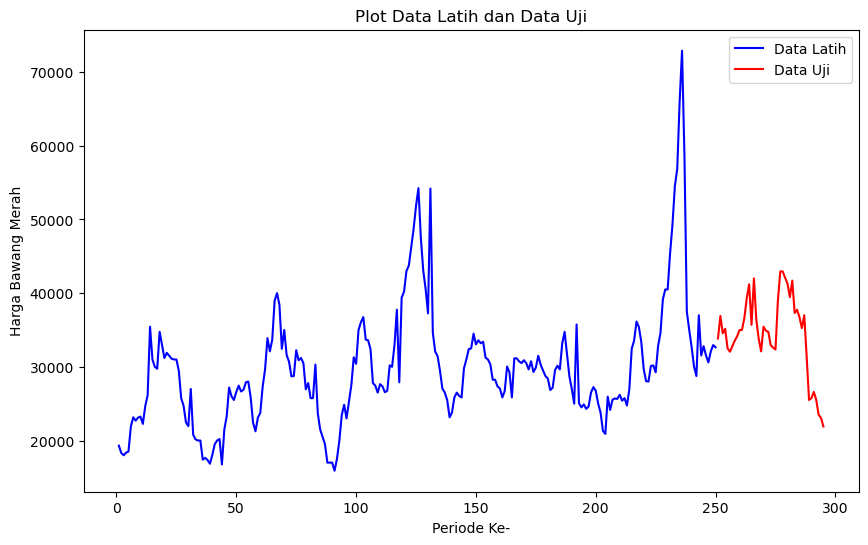

In [2]:
##EKSPLORASI DATA

# Memisahkan data menjadi data latih dan data uji
train_data = data.iloc[:250]  # Ambil 250 data pertama sebagai data latih
test_data = data.iloc[250:]   # Ambil 45 data sisanya sebagai data uji

# Menampilkan jumlah data dalam setiap bagian untuk memastikan pemisahan yang benar
print("Jumlah data latih:", len(train_data))
print("Jumlah data uji:", len(test_data))
# Membuat plot data latih dan data uji
plt.figure(figsize=(10, 6))
plt.plot(train_data['No'], train_data['BawangMerah'], label='Data Latih', color='blue')
plt.plot(test_data['No'], test_data['BawangMerah'], label='Data Uji', color='red')
plt.title('Plot Data Latih dan Data Uji')
plt.xlabel('Periode Ke-')
plt.ylabel('Harga Bawang Merah')
plt.legend()
plt.show()

In [3]:
##LSTM DAN TUNNING PARAMETER EPOCH

import numpy as np
from keras.models import Sequential
from keras.layers import LSTM, Dense
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense



# Mengambil kolom BawangMerah sebagai data yang akan diprediksi
time_series_data = data['BawangMerah'].values.reshape(-1, 1)

# Normalisasi data ke rentang 0-1
scaler = MinMaxScaler()
time_series_data = scaler.fit_transform(time_series_data)

# Membagi dataset menjadi data latih dan data uji
train_size = 250
test_size = len(time_series_data) - train_size

train_data = time_series_data[:train_size]
test_data = time_series_data[train_size:]

# Fungsi untuk membuat dataset dengan sekuens deret waktu
def create_sequences(data, seq_length):
    sequences = []
    for i in range(len(data) - seq_length):
        sequences.append(data[i : i + seq_length])
    return np.array(sequences)

# Panjang sekuens deret waktu (jumlah waktu sebelum prediksi)
seq_length = 10

# Membuat dataset dengan sekuens deret waktu
X_train = create_sequences(train_data, seq_length)
X_test = create_sequences(test_data, seq_length)

# Memisahkan fitur dan target
y_train = X_train[:, -1]
X_train = X_train[:, :-1]
y_test = X_test[:, -1]
X_test = X_test[:, :-1]

# Reshaping data untuk LSTM (jumlah sampel, panjang sekuens, jumlah fitur)
X_train = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
X_test = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)
# Fungsi untuk membuat model LSTM

def create_model():
    model = Sequential()
    model.add(LSTM(50, activation='relu', input_shape=(seq_length - 1, 1)))
    model.add(Dense(1))
    model.compile(optimizer='adam', loss='mse')
    return model

# Fungsi untuk menghitung AIC
def calculate_aic(n, mse, num_params):
    aic = n * np.log(mse) + 2 * num_params
    return aic


# Inisialisasi model
model = create_model()

# List untuk menyimpan nilai AIC pada setiap epoch
aic_values = []

# Jumlah epoch yang akan diuji
epochs_to_test = [10, 50, 100, 150, 200,250]

# Melatih model sambil menghitung AIC hanya pada epoch yang diinginkan
for epoch in epochs_to_test:
    history = model.fit(X_train, y_train, epochs=epoch, batch_size=32, verbose=0)
    
    # Prediksi dengan model
    y_pred = model.predict(X_test)
    
    # Menghitung MSE
    mse = mean_squared_error(y_test, y_pred)
    
    # Menghitung AIC
    n = len(y_test)
    num_params = len(model.trainable_weights)  # Jumlah parameter model, bisa berbeda tergantung arsitektur
    aic = calculate_aic(n, mse, num_params)
    
    # Menyimpan nilai AIC
    aic_values.append(aic)
    print(f"Epoch {epoch} - AIC: {aic}")

# Menampilkan nilai AIC per epoch yang diuji
print(aic_values)


2/2 [==============================] - 0s 8ms/step
Epoch 10 - AIC: -164.0561702630575
2/2 [==============================] - 0s 16ms/step
Epoch 50 - AIC: -184.19624835732427
2/2 [==============================] - 0s 4ms/step
Epoch 100 - AIC: -194.97287034986047
2/2 [==============================] - 0s 0s/step
Epoch 150 - AIC: -195.58093768044552
2/2 [==============================] - 0s 0s/step
Epoch 200 - AIC: -193.65251237992433
2/2 [==============================] - 0s 0s/step
Epoch 250 - AIC: -190.98540954446554
[-164.0561702630575, -184.19624835732427, -194.97287034986047, -195.58093768044552, -193.65251237992433, -190.98540954446554]


In [4]:
###LSTM FINAL DENGAN EPOCH TERBAIK

# Membangun model LSTM
model = Sequential()
model.add(LSTM(50, activation='relu', input_shape=(seq_length - 1, 1)))
model.add(Dense(1))
model.compile(optimizer='adam', loss='mse')
# Melatih model
history = model.fit(X_train, y_train, epochs=150, batch_size=32, validation_data=(X_test, y_test), verbose=10)


Epoch 1/150
Epoch 2/150
Epoch 3/150
Epoch 4/150
Epoch 5/150
Epoch 6/150
Epoch 7/150
Epoch 8/150
Epoch 9/150
Epoch 10/150
Epoch 11/150
Epoch 12/150
Epoch 13/150
Epoch 14/150
Epoch 15/150
Epoch 16/150
Epoch 17/150
Epoch 18/150
Epoch 19/150
Epoch 20/150
Epoch 21/150
Epoch 22/150
Epoch 23/150
Epoch 24/150
Epoch 25/150
Epoch 26/150
Epoch 27/150
Epoch 28/150
Epoch 29/150
Epoch 30/150
Epoch 31/150
Epoch 32/150
Epoch 33/150
Epoch 34/150
Epoch 35/150
Epoch 36/150
Epoch 37/150
Epoch 38/150
Epoch 39/150
Epoch 40/150
Epoch 41/150
Epoch 42/150
Epoch 43/150
Epoch 44/150
Epoch 45/150
Epoch 46/150
Epoch 47/150
Epoch 48/150
Epoch 49/150
Epoch 50/150
Epoch 51/150
Epoch 52/150
Epoch 53/150
Epoch 54/150
Epoch 55/150
Epoch 56/150
Epoch 57/150
Epoch 58/150
Epoch 59/150
Epoch 60/150
Epoch 61/150
Epoch 62/150
Epoch 63/150
Epoch 64/150
Epoch 65/150
Epoch 66/150
Epoch 67/150
Epoch 68/150
Epoch 69/150
Epoch 70/150
Epoch 71/150
Epoch 72/150
Epoch 73/150
Epoch 74/150
Epoch 75/150
Epoch 76/150
Epoch 77/150
Epoch 78

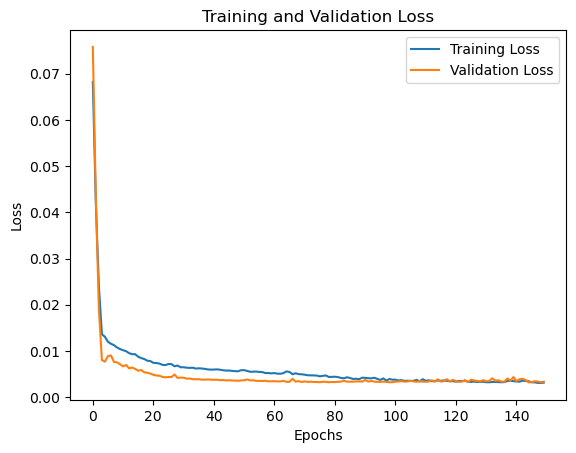

In [5]:
# Plot loss pada setiap epoch
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

2/2 [==============================] - 0s 0s/step


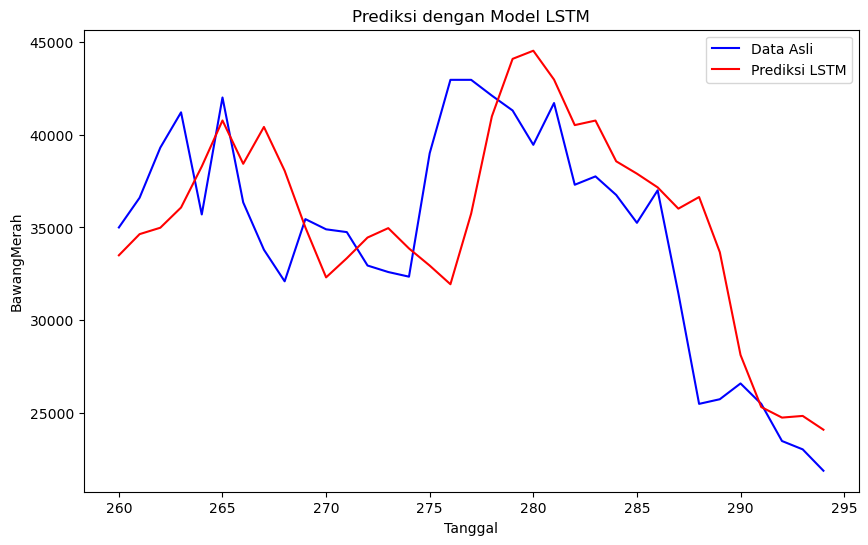

In [6]:
# Membuat prediksi dengan model LSTM
predicted = model.predict(X_test)

# Invers transform hasil prediksi ke skala aslinya
predictLSTM = scaler.inverse_transform(np.concatenate((X_test[:, -1], predicted.reshape(-1, 1)), axis=1))[:, 1]

# Plot hasil prediksi
plt.figure(figsize=(10, 6))
plt.plot(data.index[train_size + seq_length:], data['BawangMerah'].values[train_size + seq_length:], label='Data Asli', color='blue')
plt.plot(data.index[train_size + seq_length:], predictLSTM, label='Prediksi LSTM', color='red')
plt.title('Prediksi dengan Model LSTM')
plt.xlabel('Tanggal')
plt.ylabel('BawangMerah')
plt.legend()
plt.show()


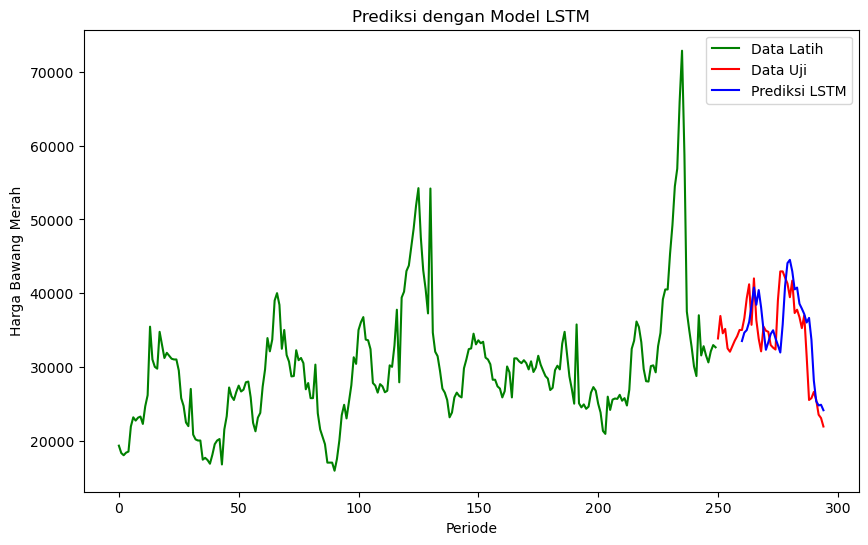

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense


# Plot data latih dan data uji beserta prediksi
plt.figure(figsize=(10, 6))
plt.plot(data.index[:train_size], data['BawangMerah'].values[:train_size], label='Data Latih', color='green')
plt.plot(data.index[train_size:], data['BawangMerah'].values[train_size:], label='Data Uji', color='red')
plt.plot(data.index[train_size + seq_length:], predictLSTM, label='Prediksi LSTM', color='blue')
plt.title('Prediksi dengan Model LSTM')
plt.xlabel('Periode')
plt.ylabel('Harga Bawang Merah')
plt.legend()
plt.show()



In [8]:
# Cek MAPE

from sklearn.metrics import mean_absolute_percentage_error
mapeLSTM = mean_absolute_percentage_error(data['BawangMerah'].values[train_size + seq_length:], predictLSTM)
print('MAPE:', mapeLSTM)

MAPE: 0.09931362960454568


1/1 [==============================] - 0s 16ms/step
Prediksi untuk 18 langkah ke depan: [[24109.26 ]
 [24107.33 ]
 [24210.13 ]
 [24300.096]
 [24598.898]
 [25014.822]
 [25524.445]
 [26003.238]
 [26507.727]
 [27015.766]
 [27514.148]
 [27975.62 ]
 [28389.057]
 [28749.602]
 [29056.121]
 [29303.133]
 [29491.23 ]
 [29635.355]]


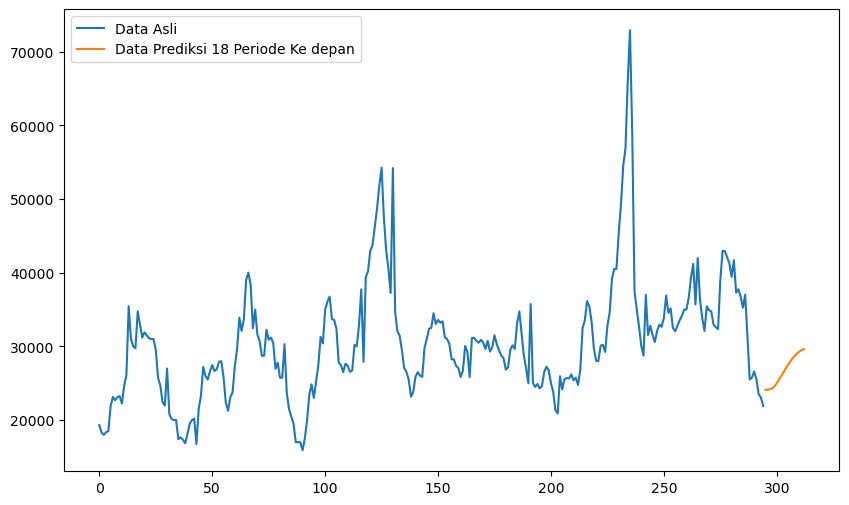

In [9]:
# Menyiapkan data untuk membuat prediksi ke depan
future_steps = 18
future_data = X_test[-1]  # Menggunakan data terakhir dari data uji sebagai awal untuk prediksi ke depan

# Membuat prediksi ke depan
future_predictions = []
for i in range(future_steps):
    prediction = model.predict(future_data.reshape(1, seq_length - 1, 1))
    future_predictions.append(prediction[0, 0])
    future_data = np.append(future_data[1:], prediction[0])  # Memperbarui data untuk prediksi berikutnya

# Invers transform hasil prediksi ke skala aslinya
future_predictions = scaler.inverse_transform(np.array(future_predictions).reshape(-1, 1))

# Menampilkan hasil prediksi ke depan
print("Prediksi untuk 18 langkah ke depan:", future_predictions)

# Visualisasi hasil prediksi ke depan bersama dengan data asli
plt.figure(figsize=(10, 6))
plt.plot(np.arange(len(time_series_data)), scaler.inverse_transform(time_series_data), label='Data Asli ')
plt.plot(np.arange(len(time_series_data), len(time_series_data) + future_steps), future_predictions, label='Data Prediksi 18 Periode Ke depan')
plt.legend()
plt.show()
